<a href="https://colab.research.google.com/github/leotamasauskas/Hybrid-Model-ARIMA-LSTM/blob/main/Hybrid_Model_ARIMA%2BLSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Importação de Bibliotecas**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive

# Montagem do Google Drive e Leitura dos **Dados**

In [ ]:
# Montar o Google Drive
drive.mount('/content/drive')

# Caminho do arquivo no Google Drive
caminho_arquivo = '/content/drive/My Drive/Dados de caxiuanã/neeCAX.txt'

# Ler o arquivo
dados = pd.read_csv(caminho_arquivo, delimiter='\t')  # Usar '\t' para separador de tabulação

# Exibir as primeiras linhas
print(dados.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
    ano  dia       NEE  PRP
0  2005    1 -2.584167  0.0
1  2005    2 -2.584167  0.0
2  2005    3 -2.584167  0.0
3  2005    4 -2.584167  0.0
4  2005    5 -2.584167  0.0


# **Tratamento dos Dados**

In [ ]:
# Verificar valores faltantes
print(dados['NEE'].isnull().sum())

# Remover linhas com valores faltantes em 'NEE'
dados = dados.dropna(subset=['NEE'])

# Converter 'ano' e 'dia' para inteiros
dados['ano'] = dados['ano'].astype(int)
dados['dia'] = dados['dia'].astype(int)

# Criar uma coluna de data
dados['data'] = pd.to_datetime(dados['ano'].astype(str) + '-' + dados['dia'].astype(str), format='%Y-%j')
dados.set_index('data', inplace=True)

# Exibir estatísticas descritivas
print(dados['NEE'].describe())

0
count    1461.000000
mean       -1.503251
std         2.551291
min       -10.190417
25%        -3.115932
50%        -1.684200
75%         0.141627
max         6.740262
Name: NEE, dtype: float64


# **Visualização da Série Temporal**

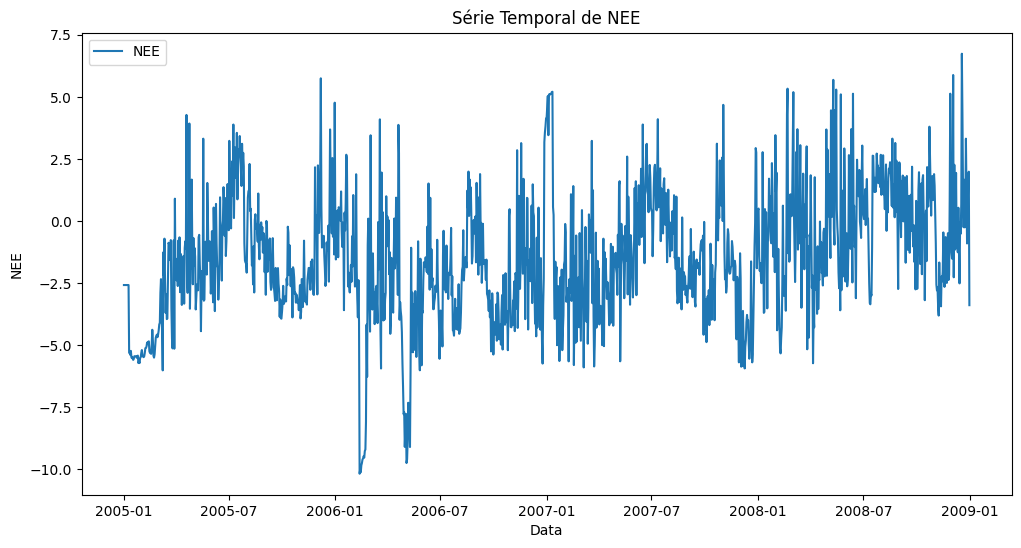

In [ ]:
# Plotar a série temporal de NEE
plt.figure(figsize=(12, 6))
plt.plot(dados.index, dados['NEE'], label='NEE')
plt.title('Série Temporal de NEE')
plt.xlabel('Data')
plt.ylabel('NEE')
plt.legend()
plt.show()

# **Teste de Estacionariedade**

Estatística ADF: -6.163830794762768
Valor-p: 7.068229447694086e-08
A série é estacionária.


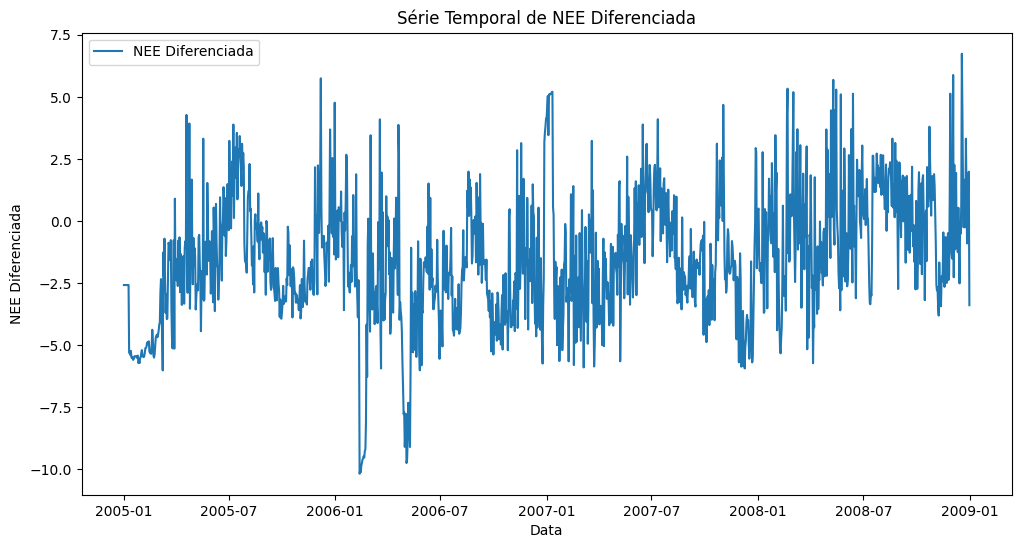

In [ ]:
# Teste ADF
result = adfuller(dados['NEE'].dropna())
print(f"Estatística ADF: {result[0]}")
print(f"Valor-p: {result[1]}")
if result[1] > 0.05:
    print("A série NÃO é estacionária. Aplicando diferenciação.")
    dados['NEE_diff'] = dados['NEE'].diff().dropna()
else:
    print("A série é estacionária.")
    dados['NEE_diff'] = dados['NEE']

# Plotar a série diferenciada
plt.figure(figsize=(12, 6))
plt.plot(dados.index, dados['NEE_diff'], label='NEE Diferenciada')
plt.title('Série Temporal de NEE Diferenciada')
plt.xlabel('Data')
plt.ylabel('NEE Diferenciada')
plt.legend()
plt.show()

# **Divisão dos Dados em Treino e Teste**

In [ ]:
# Dividir em treino e teste
train_size = int(len(dados) * 0.8)
train, test = dados.iloc[:train_size], dados.iloc[train_size:]

print(f"Tamanho do conjunto de treino: {len(train)}")
print(f"Tamanho do conjunto de teste: {len(test)}")

Tamanho do conjunto de treino: 1168
Tamanho do conjunto de teste: 293


# **Normalização dos Dados**

In [ ]:
# Normalizar NEE
scaler = MinMaxScaler()
train['NEE_scaled'] = scaler.fit_transform(train[['NEE']])
test['NEE_scaled'] = scaler.transform(test[['NEE']])

<ipython-input-56-01c843b12de5>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['NEE_scaled'] = scaler.fit_transform(train[['NEE']])
<ipython-input-56-01c843b12de5>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['NEE_scaled'] = scaler.transform(test[['NEE']])


# **Modelagem ARIMA/SARIMA**

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dat

Melhor ordem (p, d, q): (1, 0, 1) com AIC: 4548.167104598657


<ipython-input-57-67173103787d>:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['arima_pred'] = results_arima.predict(start=0, end=len(train)-1)
<ipython-input-57-67173103787d>:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['residuals'] = train['NEE_diff'] - train['arima_pred']


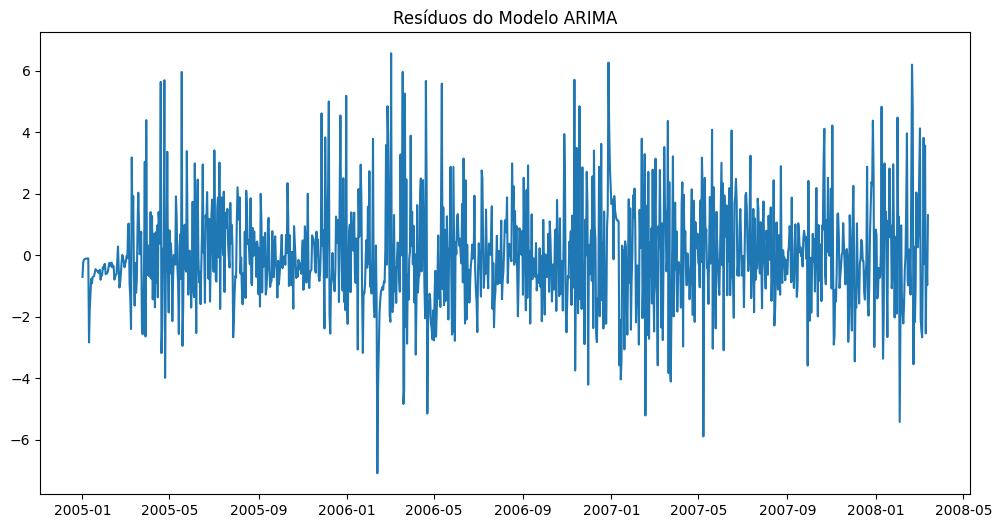

In [ ]:
# Escolher a melhor ordem (p, d, q) com base no AIC
import itertools
p = range(0, 5)
d = range(0, 2)
q = range(0, 5)
pdq = list(itertools.product(p, d, q))

best_aic = float('inf')
best_order = None

for order in pdq:
    try:
        model = ARIMA(train['NEE_diff'], order=order)
        results = model.fit()
        if results.aic < best_aic:
            best_aic = results.aic
            best_order = order
    except:
        continue

print(f"Melhor ordem (p, d, q): {best_order} com AIC: {best_aic}")

# Ajustar o modelo ARIMA com a melhor ordem
model_arima = ARIMA(train['NEE_diff'], order=best_order)
results_arima = model_arima.fit()

# Fazer previsões no conjunto de treino
train['arima_pred'] = results_arima.predict(start=0, end=len(train)-1)

# Calcular resíduos (erros)
train['residuals'] = train['NEE_diff'] - train['arima_pred']

# Visualizar resíduos
plt.figure(figsize=(12, 6))
plt.plot(train['residuals'])
plt.title('Resíduos do Modelo ARIMA')
plt.show()

# **Modelagem LSTM**

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.2319 - val_loss: 0.1170
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0923 - val_loss: 0.0358
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0497 - val_loss: 0.0268
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0412 - val_loss: 0.0257
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0374 - val_loss: 0.0244
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0382 - val_loss: 0.0211
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0304 - val_loss: 0.0201
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0304 - val_loss: 0.0198
Epoch 9/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0287 - val_loss: 0.0189
Epoch 10/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0299 - val_loss: 0.0191
Epoch 11/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0302 - val_loss: 0.0190
Epoch 12/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0290 - val_loss: 0

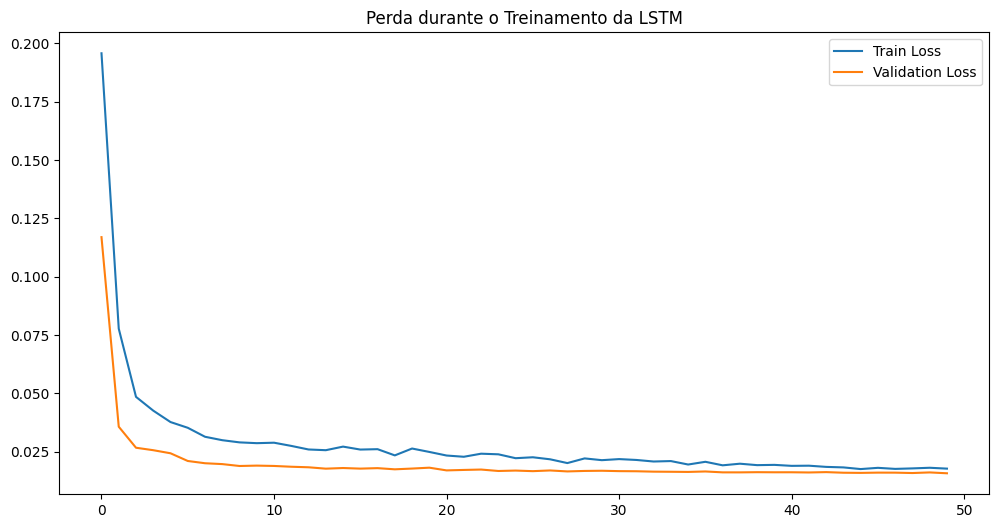

In [ ]:
# Função para criar sequências de dados para a LSTM
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

# Normalizar os resíduos
scaler_residuals = MinMaxScaler(feature_range=(0, 1))
scaled_residuals = scaler_residuals.fit_transform(train[['residuals']])

# Criar sequências para a LSTM
seq_length = 10
X, y = create_sequences(scaled_residuals, seq_length)

# Dividir em treino e validação
X_train, X_val = X[:int(len(X)*0.8)], X[int(len(X)*0.8):]
y_train, y_val = y[:int(len(y)*0.8)], y[int(len(y)*0.8):]

# Construir e treinar a LSTM com Dropout e Regularização L2
model_lstm = Sequential()
model_lstm.add(LSTM(20, activation='relu', input_shape=(seq_length, 1), kernel_regularizer=l2(0.01)))
model_lstm.add(Dropout(0.3))  # Aumentar dropout para 30%
model_lstm.add(Dense(1))
model_lstm.compile(optimizer='adam', loss='mse')

# Adicionar early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Treinar o modelo
history = model_lstm.fit(X_train, y_train, epochs=50, validation_data=(X_val, y_val), callbacks=[early_stopping], verbose=1)

# Plotar a perda durante o treinamento
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Perda durante o Treinamento da LSTM')
plt.show()

# **Previsão Híbrida e Avaliação**

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Erro Quadrático Médio no Treino: 2.87572416208565
Erro Absoluto Médio no Treino: 1.2517049711767727
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Erro Quadrático Médio no Teste: 8.538895646352183
Erro Absoluto Médio no Teste: 2.246478397335287


<ipython-input-59-130ac854b4a8>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train.loc[:, 'lstm_residuals_pred'] = lstm_residuals_pred_full
<ipython-input-59-130ac854b4a8>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train.loc[:, 'hybrid_pred'] = train['arima_pred'] + train['lstm_residuals_pred']
<ipython-input-59-130ac854b4a8>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in 

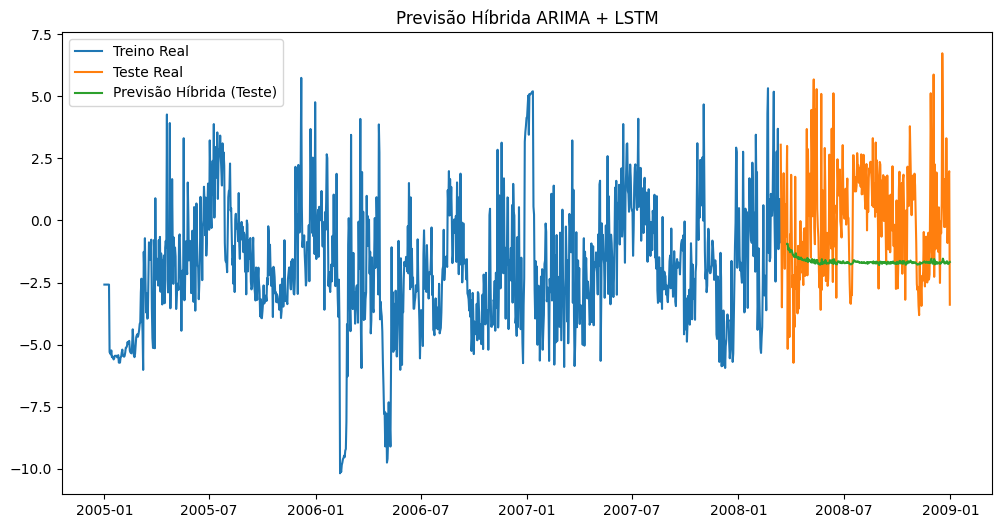

In [ ]:
# Prever resíduos no conjunto de treino com a LSTM
lstm_residuals_pred = scaler_residuals.inverse_transform(model_lstm.predict(X))

# Criar um array com NaN para as primeiras `seq_length` posições
lstm_residuals_pred_full = np.empty((len(train), 1))
lstm_residuals_pred_full[:] = np.nan
lstm_residuals_pred_full[seq_length:] = lstm_residuals_pred

# Adicionar as previsões da LSTM ao DataFrame
train.loc[:, 'lstm_residuals_pred'] = lstm_residuals_pred_full

# Previsão final (ARIMA + LSTM)
train.loc[:, 'hybrid_pred'] = train['arima_pred'] + train['lstm_residuals_pred']

# Avaliar o modelo no conjunto de treino
mse = mean_squared_error(train['NEE_diff'][seq_length:], train['hybrid_pred'][seq_length:])
mae = mean_absolute_error(train['NEE_diff'][seq_length:], train['hybrid_pred'][seq_length:])
print(f"Erro Quadrático Médio no Treino: {mse}")
print(f"Erro Absoluto Médio no Treino: {mae}")

# Prever com ARIMA no conjunto de teste
test.loc[:, 'NEE_diff'] = test['NEE'].diff().dropna()  # Aplicar diferenciação e remover NaN
test.loc[:, 'arima_pred'] = results_arima.predict(start=len(train), end=len(train)+len(test)-1)

# Calcular resíduos no teste
test.loc[:, 'residuals'] = test['NEE_diff'] - test['arima_pred']

# Preparar resíduos para a LSTM
scaled_test_residuals = scaler_residuals.transform(test[['residuals']])
X_test, y_test = create_sequences(scaled_test_residuals, seq_length)

# Prever resíduos no teste com a LSTM
lstm_test_residuals_pred = scaler_residuals.inverse_transform(model_lstm.predict(X_test))

# Criar um array com NaN para as primeiras `seq_length` posições
lstm_test_residuals_pred_full = np.empty((len(test), 1))
lstm_test_residuals_pred_full[:] = np.nan
lstm_test_residuals_pred_full[seq_length:] = lstm_test_residuals_pred

# Adicionar as previsões da LSTM ao DataFrame
test.loc[:, 'lstm_residuals_pred'] = lstm_test_residuals_pred_full

# Previsão final no teste
test.loc[:, 'hybrid_pred'] = test['arima_pred'] + test['lstm_residuals_pred']

# Remover NaN das previsões híbridas e da série diferenciada
test_cleaned = test.dropna(subset=['NEE_diff', 'hybrid_pred'])

# Avaliar o modelo no conjunto de teste
mse_test = mean_squared_error(test_cleaned['NEE_diff'], test_cleaned['hybrid_pred'])
mae_test = mean_absolute_error(test_cleaned['NEE_diff'], test_cleaned['hybrid_pred'])
print(f"Erro Quadrático Médio no Teste: {mse_test}")
print(f"Erro Absoluto Médio no Teste: {mae_test}")

# Plotar resultados
plt.figure(figsize=(12, 6))
plt.plot(train['NEE'], label='Treino Real')
plt.plot(test['NEE'], label='Teste Real')
plt.plot(test.index, test['hybrid_pred'], label='Previsão Híbrida (Teste)')
plt.legend()
plt.title('Previsão Híbrida ARIMA + LSTM')
plt.show()